In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Data Loading & Cleaning (Pandas & NumPy)
Read the dataset

In [2]:
df = pd.read_csv("samsung_global_sales_dataset.csv")
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


2. Display the shape, info, and statistical summary

In [3]:
df.shape


(15500, 28)

In [4]:
df.info()
#df["storage"]

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  str    
 1   sale_date               15500 non-null  str    
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  str    
 4   month                   15500 non-null  str    
 5   country                 15500 non-null  str    
 6   region                  15500 non-null  str    
 7   city                    15500 non-null  str    
 8   product_name            15500 non-null  str    
 9   category                15500 non-null  str    
 10  storage                 7651 non-null   str    
 11  color                   15500 non-null  str    
 12  is_5g                   15500 non-null  str    
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null  int64  
 

In [5]:
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,1.550000e+04,11249.000000
mean,2022.511935,665.116825,5.708452,2.360000,627.134001,1478.145734,1054.528710,1.595853e+06,3.743515
std,1.113496,736.014360,6.406814,1.897958,695.723305,2368.688098,4062.232887,1.092157e+07,0.721258
min,2021.000000,8.200000,0.000000,1.000000,6.600000,6.610000,0.790000,6.080000e+00,2.500000
25%,2022.000000,185.435000,0.000000,1.000000,172.780000,254.265000,1.360000,1.199072e+03,3.100000
50%,2023.000000,421.490000,3.000000,2.000000,397.410000,739.380000,10.650000,7.813940e+03,3.700000
75%,2024.000000,938.657500,10.000000,3.000000,882.907500,1695.315000,110.000000,9.126992e+04,4.400000
max,2024.000000,5442.700000,20.000000,10.000000,5442.700000,47665.900000,24500.000000,3.647727e+08,5.000000


3. Identify missing values

In [6]:
df.isnull().sum()

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   7849
color                        0
is_5g                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        9373
customer_rating           4251
return_status                0
dtype: int64

Fill missing value

In [7]:
df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())
df["customer_rating"].isnull().sum()

np.int64(0)

In [8]:
df["previous_device_os"].astype('category')
df["previous_device_os"] = df["previous_device_os"].fillna(df["previous_device_os"].mode()[0])
df["previous_device_os"].isnull().sum()

np.int64(0)

In [9]:
# product_storage = df.groupby("storage")[["product_name", "storage"]]
df["storage"] = df["storage"].fillna("0 B")
df["storage"].isnull().sum()

np.int64(0)

In [10]:
df.isnull().sum()

sale_id                   0
sale_date                 0
year                      0
quarter                   0
month                     0
country                   0
region                    0
city                      0
product_name              0
category                  0
storage                   0
color                     0
is_5g                     0
unit_price_usd            0
discount_pct              0
units_sold                0
discounted_price_usd      0
revenue_usd               0
currency                  0
fx_rate_to_usd            0
revenue_local_currency    0
sales_channel             0
payment_method            0
customer_segment          0
customer_age_group        0
previous_device_os        0
customer_rating           0
return_status             0
dtype: int64

4. Convert sale_date from a string to a Pandas DateTime object.

In [11]:
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,Android (Samsung),3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,3.7,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,Android (Samsung),4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [12]:
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["sale_date"].info()
df.head()

<class 'pandas.Series'>
RangeIndex: 15500 entries, 0 to 15499
Series name: sale_date
Non-Null Count  Dtype         
--------------  -----         
15500 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 121.2 KB


,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,Android (Samsung),3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,3.7,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,Android (Samsung),4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   sale_id                 15500 non-null  str           
 1   sale_date               15500 non-null  datetime64[us]
 2   year                    15500 non-null  int64         
 3   quarter                 15500 non-null  str           
 4   month                   15500 non-null  str           
 5   country                 15500 non-null  str           
 6   region                  15500 non-null  str           
 7   city                    15500 non-null  str           
 8   product_name            15500 non-null  str           
 9   category                15500 non-null  str           
 10  storage                 15500 non-null  str           
 11  color                   15500 non-null  str           
 12  is_5g                   15500 non-null  str           
 1

5. Verify that categorical columns like category, payment_method, and sales_channel use the category datatype to save memory.

In [14]:
df['category'] = df["category"].astype("category")
df['payment_method'] = df["payment_method"].astype("category")
df['sales_channel'] = df["sales_channel"].astype("category")
df['customer_segment'] = df["customer_segment"].astype("category")
print(df["category"].info())
print(df["payment_method"].info())
print(df["sales_channel"].info())
print(df["customer_segment"].info())
print(type(df["customer_segment"]))

<class 'pandas.Series'>
RangeIndex: 15500 entries, 0 to 15499
Series name: category
Non-Null Count  Dtype   
--------------  -----   
15500 non-null  category
dtypes: category(1)
memory usage: 15.4 KB
None
<class 'pandas.Series'>
RangeIndex: 15500 entries, 0 to 15499
Series name: payment_method
Non-Null Count  Dtype   
--------------  -----   
15500 non-null  category
dtypes: category(1)
memory usage: 15.3 KB
None
<class 'pandas.Series'>
RangeIndex: 15500 entries, 0 to 15499
Series name: sales_channel
Non-Null Count  Dtype   
--------------  -----   
15500 non-null  category
dtypes: category(1)
memory usage: 15.3 KB
None
<class 'pandas.Series'>
RangeIndex: 15500 entries, 0 to 15499
Series name: customer_segment
Non-Null Count  Dtype   
--------------  -----   
15500 non-null  category
dtypes: category(1)
memory usage: 15.3 KB
None
<class 'pandas.Series'>


6. Calculate actual_discount_amount using NumPy (df['unit_price_usd'] - df['discounted_price_usd']).

In [15]:
df["actual_discount_amount"] =np.subtract(
    df["unit_price_usd"],
    df["discounted_price_usd"]
    )

In [16]:
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status,actual_discount_amount
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,Android (Samsung),3.2,Kept,0.00
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,3.7,Kept,80.98
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept,49.22
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,Android (Samsung),4.0,Kept,0.00
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept,0.00


7. Extract the day_of_week, month, and check is_weekend from the sale_date column.

In [17]:
df["day_of_week"] = df["sale_date"].dt.day_name()
df["is_weekend"] = df["sale_date"].dt.day_of_week >= 5
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   sale_id                 15500 non-null  str           
 1   sale_date               15500 non-null  datetime64[us]
 2   year                    15500 non-null  int64         
 3   quarter                 15500 non-null  str           
 4   month                   15500 non-null  str           
 5   country                 15500 non-null  str           
 6   region                  15500 non-null  str           
 7   city                    15500 non-null  str           
 8   product_name            15500 non-null  str           
 9   category                15500 non-null  category      
 10  storage                 15500 non-null  str           
 11  color                   15500 non-null  str           
 12  is_5g                   15500 non-null  str           
 1

# Data Manipulation & Analysis

1. Filter the dataset to show only sales where the device is_5g is 'Yes' and return_status is 'Returned'.

In [18]:
df[(df["is_5g"] == "Yes") & (df["return_status"] == "Returned")]

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status,actual_discount_amount,day_of_week,is_weekend
92,SAMS-00000093,2022-04-15,2022,Q2,April,Argentina,South America,La Plata,Samsung Galaxy A53 5G,Galaxy A,...,Online (Samsung.com),Net Banking,Individual,45–54,New User,3.2,Returned,0.00,Friday,False
199,SAMS-00000200,2022-06-15,2022,Q2,June,Argentina,South America,Rosario,Samsung Galaxy A14 5G,Galaxy A,...,Online (Samsung.com),Gift Card,Individual,35–44,Android (Other),3.4,Returned,37.57,Wednesday,False
208,SAMS-00000209,2023-06-12,2023,Q2,June,Argentina,South America,Rosario,Samsung Galaxy Z Flip 5,Galaxy Z,...,Carrier Store,Net Banking,Business,45–54,Android (Samsung),3.5,Returned,0.00,Monday,False
243,SAMS-00000244,2023-03-21,2023,Q1,March,Argentina,South America,Salta,Samsung Galaxy S22,Galaxy S,...,E-commerce Platform,Samsung Pay,Education,18–24,New User,3.3,Returned,34.09,Tuesday,False
259,SAMS-00000260,2024-12-31,2024,Q4,December,Argentina,South America,Salta,Samsung Galaxy A33 5G,Galaxy A,...,Corporate / B2B,Cash,Government,35–44,Android (Samsung),4.3,Returned,54.95,Tuesday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15325,SAMS-00015326,2024-03-01,2024,Q1,March,Vietnam,Asia,Haiphong,Samsung Galaxy A53 5G,Galaxy A,...,Corporate / B2B,Cash,Individual,25–34,New User,3.0,Returned,0.00,Friday,False
15368,SAMS-00015369,2023-12-05,2023,Q4,December,Vietnam,Asia,Hanoi,Samsung Galaxy M34 5G,Galaxy M,...,Authorized Reseller,Samsung Pay,Government,55+,Android (Other),3.7,Returned,7.90,Tuesday,False
15381,SAMS-00015382,2021-05-06,2021,Q2,May,Vietnam,Asia,Ho Chi Minh City,Samsung S Pen (Galaxy S24 Ultra),Accessories,...,E-commerce Platform,Gift Card,Education,45–54,Android (Samsung),3.7,Returned,0.00,Thursday,False
15382,SAMS-00015383,2021-05-07,2021,Q2,May,Vietnam,Asia,Ho Chi Minh City,Samsung Galaxy Z Fold 5,Galaxy Z,...,Authorized Reseller,Debit Card,Education,18–24,Android (Other),4.9,Returned,0.00,Friday,False


2. Find the total revenue_usd by region and country using .groupby().

In [19]:
df.groupby(["country", "region"])["revenue_usd"].sum()


country         region       
Argentina       South America    455726.16
Australia       Oceania          437532.39
Austria         Europe           529642.09
Bangladesh      Asia             484306.00
Belgium         Europe           361647.50
Brazil          South America    404509.74
Canada          North America    515495.34
Chile           South America    463495.60
China           Asia             380012.21
Colombia        South America    441768.22
Czech Republic  Europe           444956.19
Denmark         Europe           421990.10
Egypt           Africa           439261.56
Ethiopia        Africa           391058.82
France          Europe           522563.49
Germany         Europe           429448.96
Greece          Europe           551966.07
India           Asia             468730.51
Indonesia       Asia             459696.89
Italy           Europe           442618.87
Japan           Asia             416493.84
Kenya           Africa           445910.10
Malaysia        Asia    

3. Calculate the average customer_rating per product 'category'

In [20]:
df.groupby("category")["customer_rating"].mean()

category
Accessories     3.745550
Appliances      3.778802
Galaxy A        3.735359
Galaxy Buds     3.702417
Galaxy M        3.752149
Galaxy S        3.729922
Galaxy Tab      3.712795
Galaxy Watch    3.708748
Galaxy Z        3.702836
Monitor         3.737859
Smart TV        3.740618
Name: customer_rating, dtype: float64

4. Create a pivot table showing the total units_sold with payment_method as rows and region as columns.

In [21]:
df.pivot_table(
    columns="region", 
    index="payment_method", 
    values="units_sold", 
    aggfunc= sum)

region,Africa,Asia,Europe,Europe/Asia,Middle East,North America,Oceania,South America
payment_method,,,,,,,,
BNPL (Buy Now Pay Later),428,1387,1536,123,184,257,179,436
Cash,435,1249,1692,153,213,291,219,463
Credit Card,414,1347,1513,180,153,305,161,456
Debit Card,465,1293,1490,195,125,260,171,419
EMI / Installment,502,1312,1610,157,234,229,170,426
Gift Card,455,1361,1588,174,142,256,154,418
Net Banking,408,1490,1625,153,158,267,151,369
Samsung Pay,415,1300,1463,251,199,304,168,479


5. Find the top 10 most popular product_names based on the sum of units_sold.

In [22]:
df.groupby("product_name")["units_sold"].sum().sort_values(ascending = False).head(10)

product_name
Samsung Galaxy Tab S9 FE        628
Samsung Galaxy S23              610
Samsung Galaxy M04              599
Samsung Galaxy A24              586
Samsung Galaxy A34 5G           583
Samsung Galaxy Tab S9           579
Samsung Wireless Charger Pad    572
Samsung 32GB MicroSD Card       558
Samsung Galaxy Buds Live        557
Samsung Galaxy S22              555
Name: units_sold, dtype: int64

6. Use pd.crosstab() to see the relationship and counts between customer_age_group and category.

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   sale_id                 15500 non-null  str           
 1   sale_date               15500 non-null  datetime64[us]
 2   year                    15500 non-null  int64         
 3   quarter                 15500 non-null  str           
 4   month                   15500 non-null  str           
 5   country                 15500 non-null  str           
 6   region                  15500 non-null  str           
 7   city                    15500 non-null  str           
 8   product_name            15500 non-null  str           
 9   category                15500 non-null  category      
 10  storage                 15500 non-null  str           
 11  color                   15500 non-null  str           
 12  is_5g                   15500 non-null  str           
 1

In [24]:
pd.crosstab(df["category"], df["customer_age_group"],)

customer_age_group,18–24,25–34,35–44,45–54,55+
category,,,,,
Accessories,371,447,416,412,455
Appliances,190,222,217,221,202
Galaxy A,402,403,350,367,370
Galaxy Buds,172,186,165,198,148
Galaxy M,181,176,164,170,170
Galaxy S,457,499,457,429,474
Galaxy Tab,309,306,294,324,291
Galaxy Watch,279,311,297,297,302
Galaxy Z,211,209,217,211,210


# Static Visualization
1. Plot the total monthly revenue_usd over the years (2021-2024) to identify seasonal trends

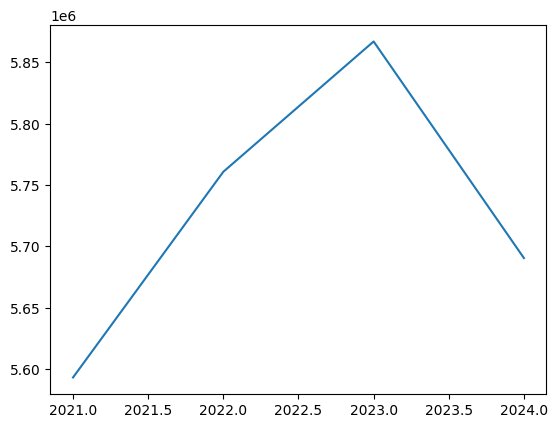

In [ ]:
monthly_revenue = df.groupby("year")["revenue_usd"].sum()
plt.plot(monthly_revenue.index, monthly_revenue.values)

2. Plot the top 5 countrys by total revenue generated.

<BarContainer object of 5 artists>

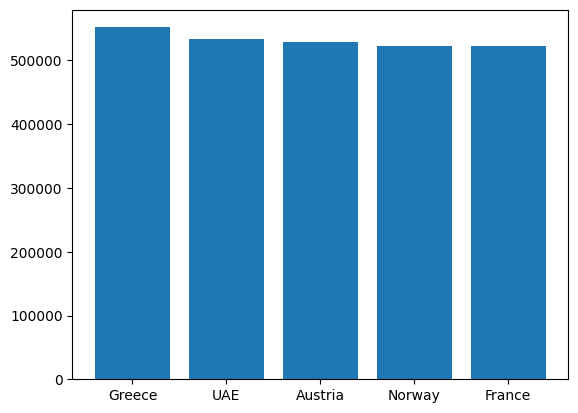

In [ ]:
sum_of_revenue = df.groupby("country")["revenue_usd"].sum()
top_5_country = sum_of_revenue.sort_values(ascending = False).head()
plt.bar(top_5_country.index, top_5_country.values)